# InfraBayesian vs Bayesian Agent Comparison

Compare the InfraBayesianAgent (non-KU, single a-measure) against the existing BayesianAgent across all environments.

**Expectation**: Without Knightian uncertainty, the IB framework reduces to standard Bayesian updating. By using `GaussianBelief` (which replicates BayesianAgent's exact update math) inside the IB agent, performance on bandit-like environments should be **identical** — proving the AMeasure/Infradistribution plumbing is a true no-op in non-KU mode.

On Newcomb-like environments, the IB agent uses `NewcombLikeBelief` (tracks the full reward matrix), while BayesianAgent only tracks per-arm means. This is a model difference, not a framework difference — the IB agent has a structural advantage because it models the game.

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

from ibrl.simulators import simulate
from ibrl.utils import construct_environment
from ibrl.agents import BayesianAgent, InfraBayesianAgent
from ibrl.infrabayesian.beliefs import GaussianBelief, NewcombLikeBelief

## Configuration

In [ ]:
# Environments to test, grouped by type
bandit_envs = ["bandit", "switching"]
newcomb_envs = ["newcomb", "damascus", "asymmetric-damascus", "coordination", "pdbandit"]

all_envs = bandit_envs + newcomb_envs

options = {
    "num_actions": 2,
    "num_steps":   500,
    "num_runs":    20,
    "seed":        42,
    "verbose":     0,
}

def make_agents(env_name):
    """Build the two agents to compare, choosing the right belief for the IB agent.
    
    For bandit-like envs: GaussianBelief matches BayesianAgent's exact update math,
    so performance should be identical (proves IB plumbing is a no-op).
    
    For Newcomb-like envs: NewcombLikeBelief tracks the full reward matrix,
    giving the IB agent a structural advantage over BayesianAgent.
    """
    shared = dict(num_actions=options["num_actions"], seed=options["seed"] + 0x01234567)

    bayesian = BayesianAgent(**shared, epsilon=0.1)

    if env_name in bandit_envs:
        belief = GaussianBelief(num_actions=options["num_actions"])
    else:
        belief = NewcombLikeBelief(num_actions=options["num_actions"])

    ib = InfraBayesianAgent(**shared, belief=belief, epsilon=0.1)

    return {"bayesian": bayesian, "infrabayesian": ib}

## Run experiments

In [3]:
all_results = {}

for env_name in all_envs:
    all_results[env_name] = {}
    env = construct_environment(env_name, options)
    agents = make_agents(env_name)

    for agent_name, agent in agents.items():
        label = f"{env_name} / {agent_name}"
        print(f"Running: {label}")

        results = simulate(env, agent, options)
        all_results[env_name][agent_name] = results

        print(f"  optimal: {results['optimal_reward']:.4f}  "
              f"final avg: {results['average_reward'][0, -1]:.4f}")

print("\nDone.")

Running: bandit / bayesian
  optimal: 0.7278  final avg: 0.7500
Running: bandit / infrabayesian
  optimal: 0.7369  final avg: 0.6000
Running: switching / bayesian
  optimal: 1.0000  final avg: 0.4500
Running: switching / infrabayesian
  optimal: 1.0000  final avg: 0.5500
Running: newcomb / bayesian
  optimal: 1.0000  final avg: 0.6400
Running: newcomb / infrabayesian
  optimal: 1.0000  final avg: 1.0050
Running: damascus / bayesian
  optimal: 0.5000  final avg: 0.0500
Running: damascus / infrabayesian
  optimal: 0.5000  final avg: 0.5500
Running: asymmetric-damascus / bayesian
  optimal: 0.6667  final avg: 0.5500
Running: asymmetric-damascus / infrabayesian
  optimal: 0.6667  final avg: 0.5500
Running: coordination / bayesian
  optimal: 2.0000  final avg: 1.1500
Running: coordination / infrabayesian
  optimal: 2.0000  final avg: 1.8500
Running: pdbandit / bayesian
  optimal: 0.7760  final avg: 0.5041
Running: pdbandit / infrabayesian
  optimal: 0.5993  final avg: 0.3288

Done.


## Cumulative regret comparison

One subplot per environment. Both agents plotted together so we can directly compare learning curves.

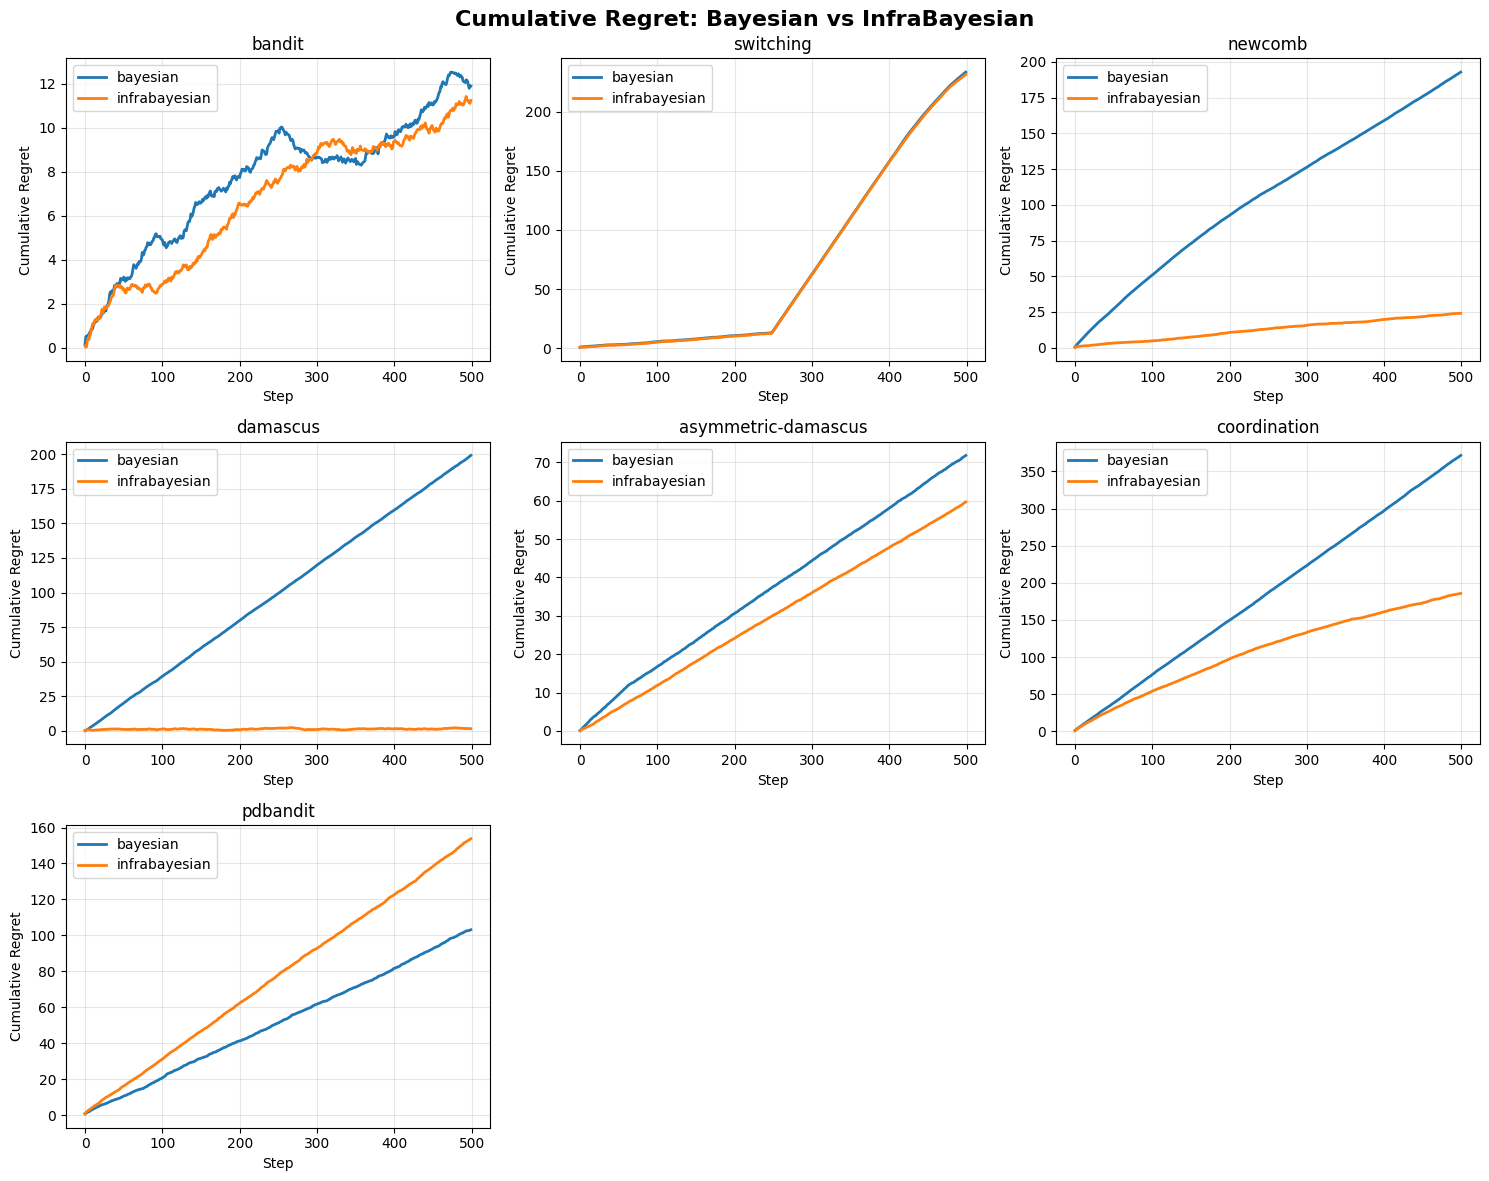

In [4]:
cols = 3
rows = math.ceil(len(all_envs) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

for i, env_name in enumerate(all_envs):
    ax = axes[i]
    for agent_name, res in all_results[env_name].items():
        avg_reward = res["average_reward"][0, :]
        optimal = res["optimal_reward"]
        cumulative_regret = np.cumsum(optimal - avg_reward)
        ax.plot(cumulative_regret, label=agent_name, linewidth=2)
    ax.set_title(env_name)
    ax.set_xlabel("Step")
    ax.set_ylabel("Cumulative Regret")
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(len(all_envs), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Cumulative Regret: Bayesian vs InfraBayesian", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## Selection probabilities

Per-agent, per-environment view of how the policy evolves over time.

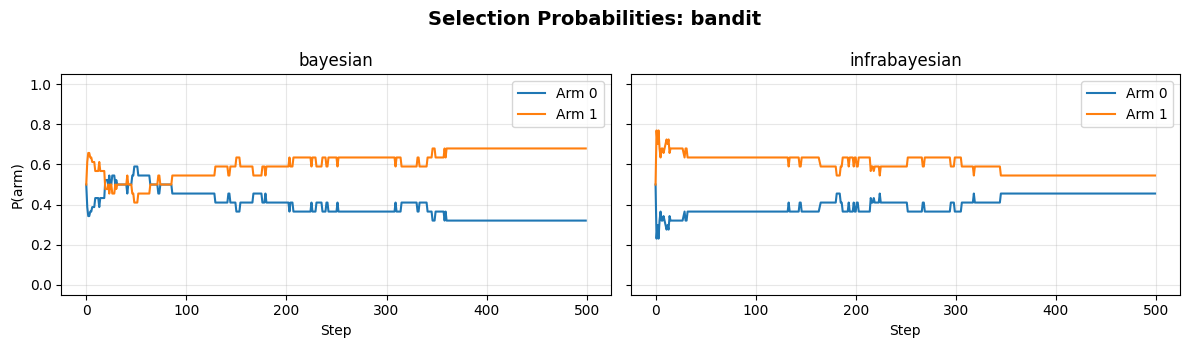

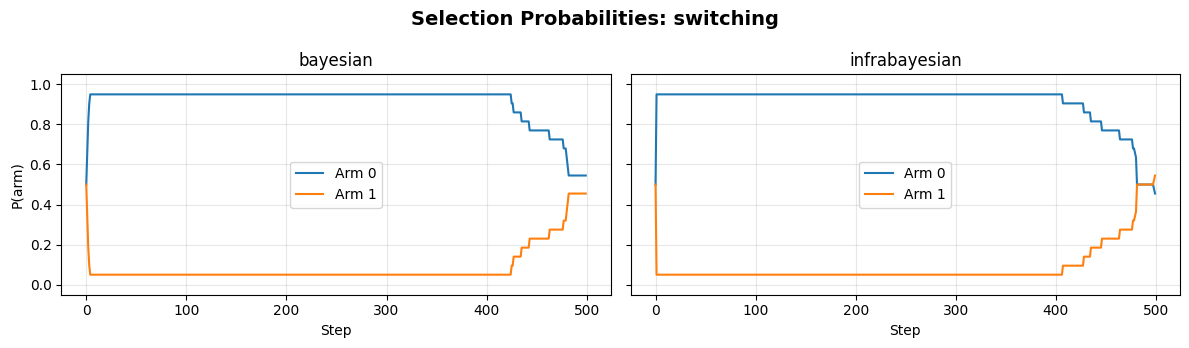

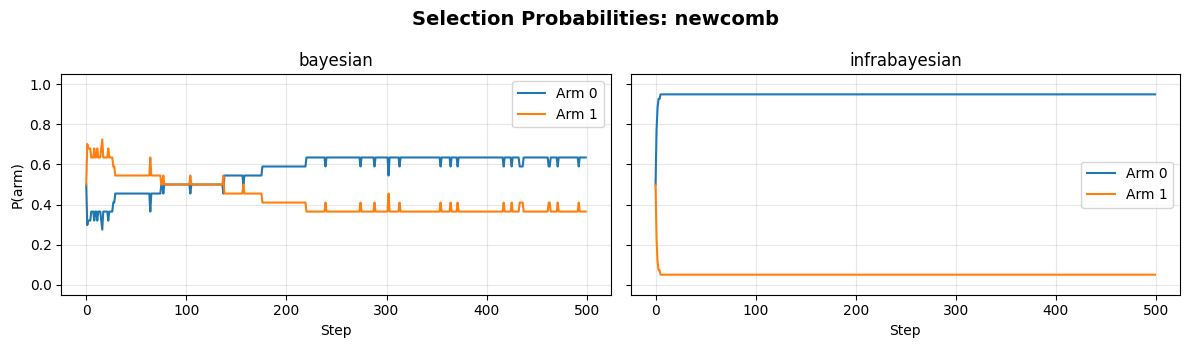

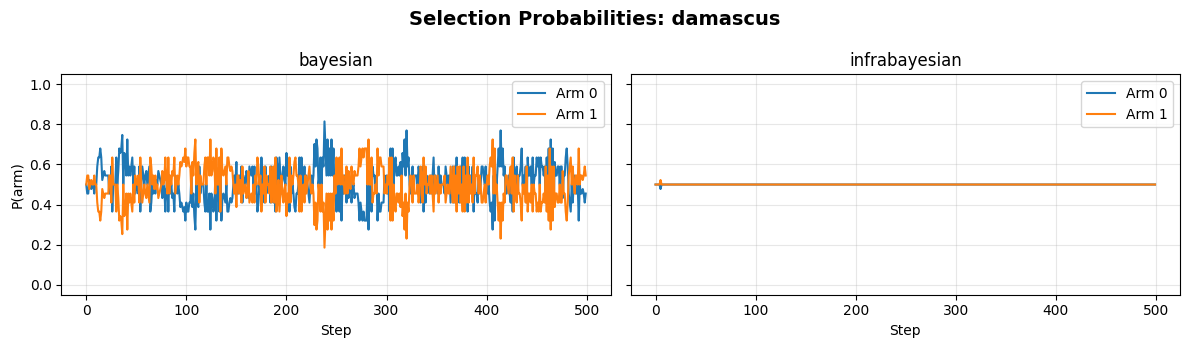

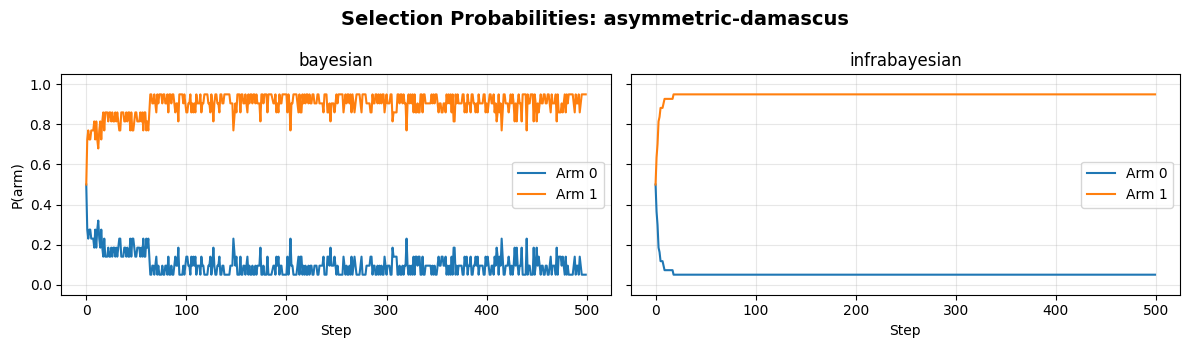

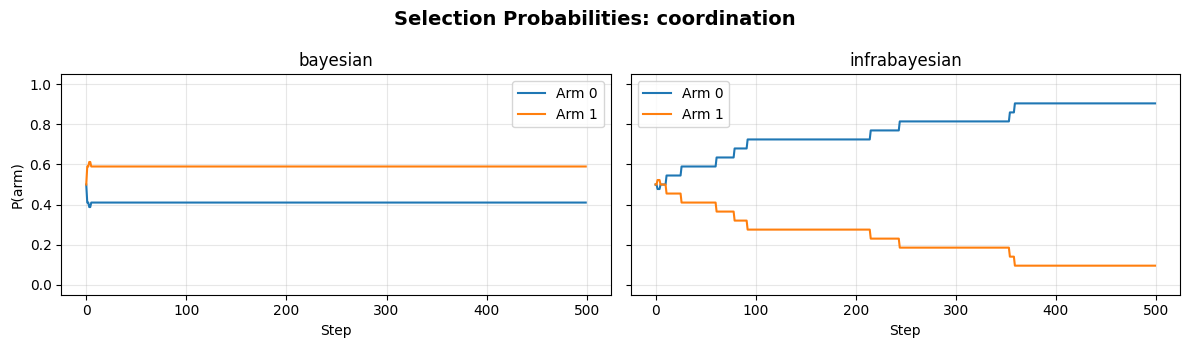

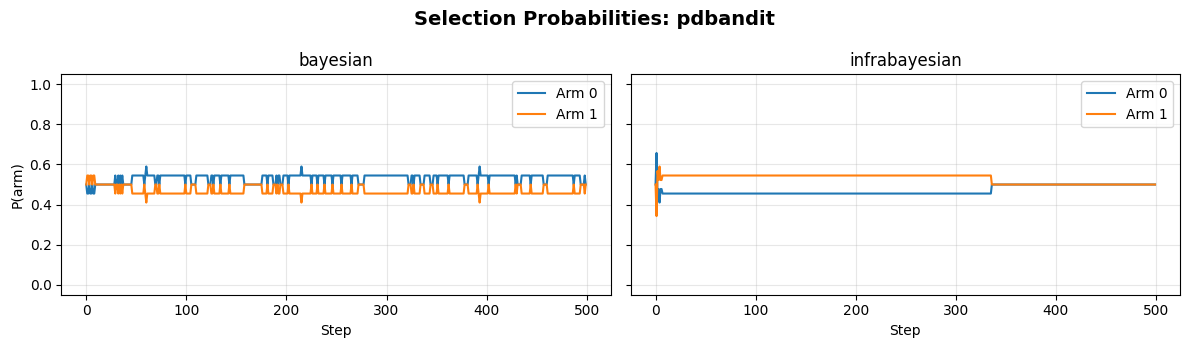

In [5]:
agent_names = ["bayesian", "infrabayesian"]
k = options["num_actions"]

for env_name in all_envs:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
    fig.suptitle(f"Selection Probabilities: {env_name}", fontsize=14, fontweight="bold")

    for j, agent_name in enumerate(agent_names):
        ax = axes[j]
        res = all_results[env_name][agent_name]
        for arm in range(k):
            ax.plot(res["probabilities"][:, :, arm].mean(axis=0), label=f"Arm {arm}")
        ax.set_title(agent_name)
        ax.set_xlabel("Step")
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        if j == 0:
            ax.set_ylabel("P(arm)")
        ax.legend()

    plt.tight_layout()
    plt.show()

## Summary table

In [ ]:
print(f"{'Environment':<25} {'Optimal':>8} {'Bayesian':>10} {'IB':>10} {'Diff':>8}")
print("-" * 65)
for env_name in all_envs:
    optimal = all_results[env_name]["bayesian"]["optimal_reward"]
    bay_final = all_results[env_name]["bayesian"]["average_reward"][0, -50:].mean()
    ib_final = all_results[env_name]["infrabayesian"]["average_reward"][0, -50:].mean()
    diff = ib_final - bay_final
    print(f"{env_name:<25} {optimal:>8.3f} {bay_final:>10.3f} {ib_final:>10.3f} {diff:>+8.3f}")